# How to access the Normalized digital surface model with stac

In [1]:
from odc import stac as odc_stac
import xarray as xr
import matplotlib.pyplot as plt
import geopandas
import numpy as np
from pystac_client import Client

## Connect to the eodc stac

In [2]:
eodc_catalog = Client.open(
    "https://stac.eodc.eu/api/v1",
)

In [ ]:
# Select the region
bbox = [16.75, 47.92, 16.79, 47.95]

# Normalized digital surface model (if you want to use the Digital terrain model use collections=["topo-dc-austria-dtm"] and for the Digital surface model use collections=["topo-dc-austria-dsm"])
search = eodc_catalog.search(
    collections=["topo-dc-austria-ndsm"],
    # collections=["topo-dc-austria-dtm"],
    # collections=["topo-dc-austria-dsm"],
    bbox = bbox,
)


print("We found ", search.matched(), " items, that match our filter criteria.")

items = search.items()

We found  16  items, that match our filter criteria.


## Select all items with the datetime 2024

Even if the time of the data is 2024 the time of the collected data is 2023, so keep that in mind depending on what you want to calculate

In [4]:
items_2024 = []
for item in items:
    dt = item.properties.get("datetime", "")
    if dt.startswith("2024"):
        items_2024.append(item)

In [5]:
items_2024

[<Item id=N2785312_E4827535_nDSM_2024>,
 <Item id=N2785312_E4823439_nDSM_2024>,
 <Item id=N2781216_E4827535_nDSM_2024>,
 <Item id=N2781216_E4823439_nDSM_2024>]

## Create a xarray dataset from the items

In [6]:
crs = "EPSG:3035"   # native CRS
res = 1             # meters (from gsd)

ds_2024 = odc_stac.load(
    items_2024,
    crs=crs,
    resolution=res,
    bbox=bbox, 
)


In [7]:
print(ds_2024)

<xarray.Dataset> Size: 94MB
Dimensions:      (y: 3597, x: 3274, time: 1)
Coordinates:
  * y            (y) float64 29kB 2.783e+06 2.783e+06 ... 2.779e+06 2.779e+06
  * x            (x) float64 26kB 4.825e+06 4.825e+06 ... 4.828e+06 4.828e+06
    spatial_ref  int32 4B 3035
  * time         (time) datetime64[ns] 8B 2024-09-15
Data variables:
    data         (time, y, x) float32 47MB 0.4529 0.1094 0.0 0.0 ... 0.0 0.0 0.0
    mask         (time, y, x) float32 47MB 255.0 255.0 255.0 ... 255.0 255.0


In [9]:
# print some values
ds_2024["data"].isel(time=0, y=slice(0, 5), x=slice(0, 5)).values


array([[4.52926636e-01, 1.09436035e-01, 0.00000000e+00, 0.00000000e+00,
        2.13623047e-04],
       [1.28112793e-01, 2.02941895e-02, 0.00000000e+00, 4.42504883e-04,
        4.27246094e-04],
       [0.00000000e+00, 0.00000000e+00, 3.50952148e-04, 3.35693359e-04,
        4.73022461e-04],
       [1.37329102e-04, 3.05175781e-05, 0.00000000e+00, 4.57763672e-05,
        1.52587891e-04],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00]], dtype=float32)

## Plot only the data

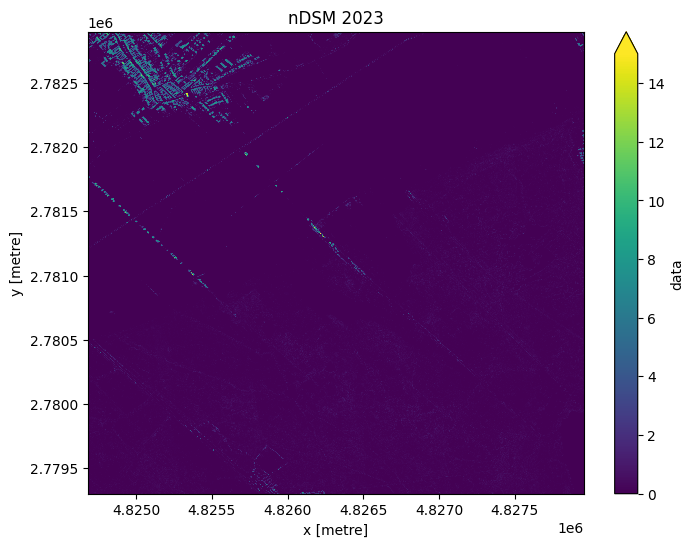

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
ds_2024["data"].isel(time=0).plot(
    cmap="viridis",
    vmin=0,
    vmax=15
)
plt.title("nDSM 2023")
plt.show()


## Plot the masked data

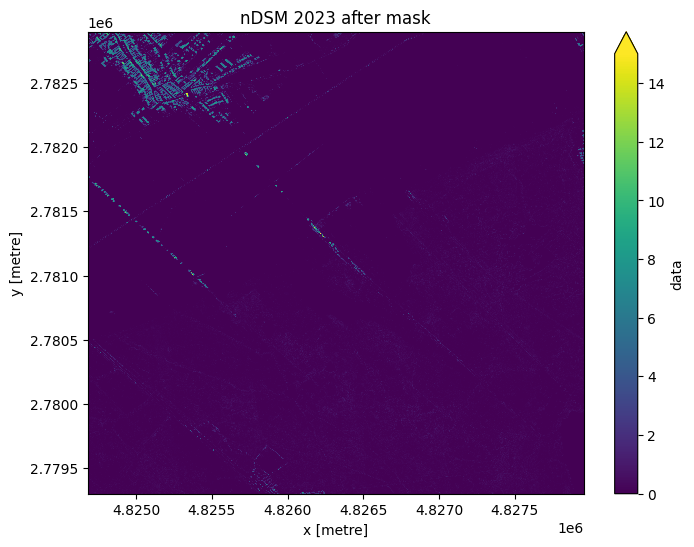

In [37]:
da = ds_2024["data"].isel(time=0)
mask = ds_2024["mask"].isel(time=0)

da_masked = da.where(mask == 255)

plt.figure(figsize=(8, 6))
da_masked.plot(
    cmap="viridis",
    vmin=0,
    vmax=15
)
plt.title("nDSM 2023 after mask")
plt.show()


## Create a dataset from all years
Sometimes you need to run the stac search again to make it work

In [ ]:
crs = "EPSG:3035"   # native CRS -> known from the stac metadata
res = 1             # meters

ds_combined = odc_stac.load(
    items,
    crs=crs,
    resolution=res,
    bbox=bbox, 
)

print(ds_combined)

<xarray.Dataset> Size: 377MB
Dimensions:      (y: 3597, x: 3274, time: 4)
Coordinates:
  * y            (y) float64 29kB 2.783e+06 2.783e+06 ... 2.779e+06 2.779e+06
  * x            (x) float64 26kB 4.825e+06 4.825e+06 ... 4.828e+06 4.828e+06
    spatial_ref  int32 4B 3035
  * time         (time) datetime64[ns] 32B 2021-09-15 2022-09-15 ... 2024-09-15
Data variables:
    data         (time, y, x) float32 188MB 0.8824 0.007553 0.0 ... 0.0 0.0 0.0
    mask         (time, y, x) float32 188MB 255.0 255.0 255.0 ... 255.0 255.0


If you have you AOI in geographical coordinates you need to convert them into projected coordinates (as the data is in ETRS89).
Otherwise you can ignore this step

In [13]:
from pyproj import Transformer

lon_min, lat_min, lon_max, lat_max = 16.773838,47.934488,16.773908,47.934538

t = Transformer.from_crs("EPSG:4326", "EPSG:3035", always_xy=True)
x_min, y_min = t.transform(lon_min, lat_min)
x_max, y_max = t.transform(lon_max, lat_max)

# make sure min/max are ordered
x0, x1 = sorted([x_min, x_max])
y0, y1 = sorted([y_min, y_max])

print(x0, y0, x1, y1)


4826606.8683285285 2781068.5887244726 4826611.581265222 2781074.605533941


## Create a subset for detailed analysis

In [14]:
subset = ds_combined.sel(
    x=slice(x0, x1),
    y=slice(y1, y0),
)

In [15]:
subset

<xarray.Dataset> Size: 1kB
Dimensions:      (y: 6, x: 5, time: 4)
Coordinates:
  * y            (y) float64 48B 2.781e+06 2.781e+06 ... 2.781e+06 2.781e+06
  * x            (x) float64 40B 4.827e+06 4.827e+06 ... 4.827e+06 4.827e+06
    spatial_ref  int32 4B 3035
  * time         (time) datetime64[ns] 32B 2021-09-15 2022-09-15 ... 2024-09-15
Data variables:
    data         (time, y, x) float32 480B 0.0 0.0005722 ... 0.0003815 0.0005188
    mask         (time, y, x) float32 480B 255.0 255.0 255.0 ... 255.0 255.0

## Calculate the mean of all pixels for every year and plot them

In [16]:
data = subset["data"].where(subset["mask"] == 255)

ts_mean = data.mean(dim=("y", "x"))
print(ts_mean.values)

[0.00162608 0.00169907 0.00152791 0.00162582]


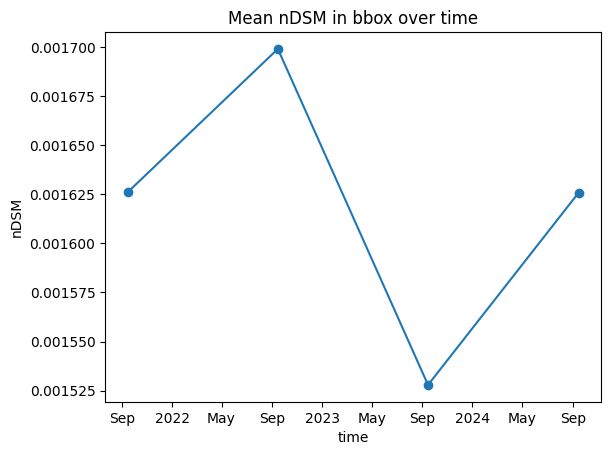

In [17]:
ts_mean.plot(marker="o")
plt.title("Mean nDSM in bbox over time")
plt.ylabel("nDSM")
plt.show()

## Plot the trajectories of each pixel over the years

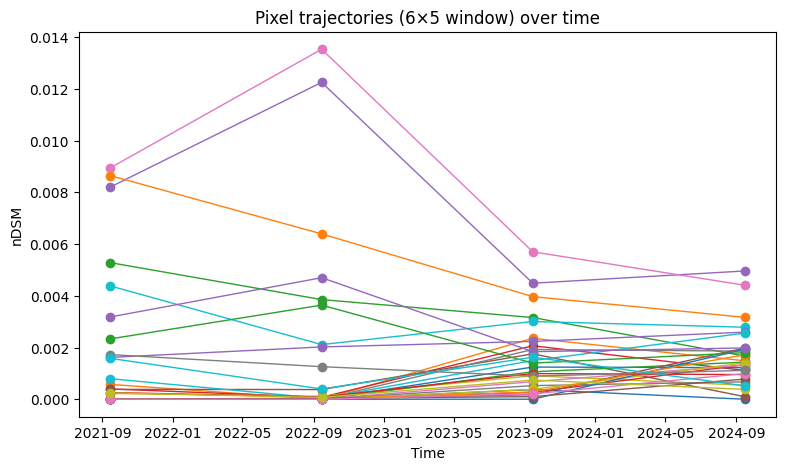

In [ ]:
sub_data = subset["data"]              # (time, y, x)
pix = sub_data.stack(pixel=("y", "x"))  # (time, pixel)

plt.figure(figsize=(9, 5))
for i in range(pix.sizes["pixel"]):
    plt.plot(pix["time"].values, pix.isel(pixel=i).values, marker="o", linewidth=1)


plt.title("Pixel trajectories (6×5 window) over time")
plt.xlabel("Time")
plt.ylabel("nDSM")
plt.show()